This notebook runs model training + evaluation pipeline on Scheme A, random cell-level split.

In [ ]:
# This notebook runs the model training + evaluation pipeline for Scheme A:
# random cell-level train/test split across all transcriptomic representations.

###################SCRIPT B##########################
# --------------------
# Imports
# --------------------
import os
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)

# --------------------
# Set repo root and load data
# --------------------
REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()  # change if needed
os.chdir(REPO_ROOT)

adata = sc.read_h5ad("data/adata_processed.h5ad")

# --------------------
# Settings
# --------------------
CELLTYPE_COL = "cell_type"
RANDOM_STATE = 42
TEST_SIZE = 0.2

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

REPRESENTATIONS = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

# --------------------
# Helper functions
# --------------------
def get_representation(adata, rep_name):
    if rep_name == "hvg":
        X = adata.X
    else:
        X = adata.obsm[rep_name]

    if hasattr(X, "toarray"):
        X = X.toarray()
    else:
        X = np.asarray(X)

    return X


def run_random_split_logreg(
    adata,
    rep_name,
    celltype_col=CELLTYPE_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
):
    X = get_representation(adata, rep_name)
    y = adata.obs[celltype_col].astype(str)

    counts = y.value_counts()
    keep_labels = counts[counts >= 2].index
    keep_mask = y.isin(keep_labels)

    X = X[keep_mask.to_numpy()]
    y = y[keep_mask].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = LogisticRegression(
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    labels = np.unique(y)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    macro_f1 = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )

    per_class_f1 = pd.DataFrame({
        "cell_type": labels,
        "f1": [report[label]["f1-score"] for label in labels],
        "precision": [report[label]["precision"] for label in labels],
        "recall": [report[label]["recall"] for label in labels],
        "support": [report[label]["support"] for label in labels],
    })

    return {
        "model": clf,
        "y_test": y_test,
        "y_pred": y_pred,
        "macro_f1": macro_f1,
        "accuracy": acc,
        "cm": cm,
        "labels": labels,
        "per_class_f1": per_class_f1,
        "n_cells_used": len(y),
        "n_classes_used": len(labels),
    }


def save_confusion_matrix(cm, labels, out_file, title, normalize=False):
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm.astype(float),
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )
    else:
        cm_plot = cm

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_plot, display_labels=labels)
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=True,
        values_format=None,
    )

    # remove in-cell text for readability
    if disp.text_ is not None:
        for text in disp.text_.ravel():
            if text is not None:
                text.set_visible(False)

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()


# --------------------
# Run Scheme A for all representations
# --------------------
metrics_rows = []

for rep_label, rep_key in REPRESENTATIONS.items():
    print(f"Running Scheme A for {rep_label} ({rep_key})...")

    res = run_random_split_logreg(adata, rep_name=rep_key)

    print(f"  Macro F1: {res['macro_f1']:.4f}")
    print(f"  Accuracy: {res['accuracy']:.4f}")

    # save per-class metrics
    res["per_class_f1"].to_csv(
        results_dir / f"schemeA_{rep_label}_per_class_f1.csv",
        index=False
    )

    # save full confusion matrix as csv
    cm_df = pd.DataFrame(res["cm"], index=res["labels"], columns=res["labels"])
    cm_df.to_csv(results_dir / f"schemeA_{rep_label}_confusion_matrix.csv")

    # save normalized confusion matrix plot
    save_confusion_matrix(
        res["cm"],
        res["labels"],
        results_dir / f"schemeA_{rep_label}_confusion_matrix_normalized.png",
        title=f"Scheme A Random Split - {rep_label} (row-normalized)",
        normalize=True,
    )

    # append summary row
    metrics_rows.append({
        "scheme": "random",
        "representation": rep_label,
        "macro_f1": res["macro_f1"],
        "accuracy": res["accuracy"],
        "n_cells_used": res["n_cells_used"],
        "n_classes_used": res["n_classes_used"],
    })

# --------------------
# Save overall metrics table
# --------------------
metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
metrics_df.to_csv(results_dir / "metrics.csv", index=False)

print("\nFinal Scheme A metrics:")
print(metrics_df)

Running Scheme A for hvg (hvg)...
  Macro F1: 0.4766
  Accuracy: 0.7967
Running Scheme A for pca (X_pca)...
  Macro F1: 0.5008
  Accuracy: 0.7786
Running Scheme A for harmony (X_harmony)...
  Macro F1: 0.4542
  Accuracy: 0.7533
Running Scheme A for scvi (X_scVI)...
  Macro F1: 0.5079
  Accuracy: 0.7586

Final Scheme A metrics:
   scheme representation  macro_f1  accuracy  n_cells_used  n_classes_used
0  random           scvi  0.507904  0.758636         11289              40
1  random            pca  0.500756  0.778565         11289              40
2  random            hvg  0.476643  0.796723         11289              40
3  random        harmony  0.454162  0.753322         11289              40


In [27]:
# This notebook runs the model training + evaluation pipeline for Scheme B:
# donor-held-out train/test split across all transcriptomic representations.

# --------------------
# Imports
# --------------------
import os
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)

# --------------------
# Set repo root and load data
# --------------------
REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()  # change if needed
os.chdir(REPO_ROOT)

adata = sc.read_h5ad("data/adata_processed.h5ad")

# --------------------
# Settings
# --------------------
CELLTYPE_COL = "cell_type"
DONOR_COL = "patient_id"
RANDOM_STATE = 42
TEST_SIZE = 0.2

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

REPRESENTATIONS = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

# --------------------
# Helper functions
# --------------------
def get_representation(adata, rep_name):
    if rep_name == "hvg":
        X = adata.X
    else:
        X = adata.obsm[rep_name]

    if hasattr(X, "toarray"):
        X = X.toarray()
    else:
        X = np.asarray(X)

    return X


def run_donor_holdout_logreg(
    adata,
    rep_name,
    celltype_col=CELLTYPE_COL,
    donor_col=DONOR_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
):
    X = get_representation(adata, rep_name)
    y = adata.obs[celltype_col].astype(str)
    donors = adata.obs[donor_col].astype(str)

    # split by donor
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups=donors))

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y.iloc[train_idx].to_numpy()
    y_test = y.iloc[test_idx].to_numpy()
    donor_train = donors.iloc[train_idx].to_numpy()
    donor_test = donors.iloc[test_idx].to_numpy()

    # keep only cell types that appear in BOTH train and test
    train_labels = pd.Series(y_train).value_counts()
    test_labels = pd.Series(y_test).value_counts()

    shared_labels = sorted(set(train_labels.index) & set(test_labels.index))

    train_mask = np.isin(y_train, shared_labels)
    test_mask = np.isin(y_test, shared_labels)

    X_train = X_train[train_mask]
    X_test = X_test[test_mask]
    y_train = y_train[train_mask]
    y_test = y_test[test_mask]
    donor_train = donor_train[train_mask]
    donor_test = donor_test[test_mask]

    # logistic regression needs at least 2 classes in train
    final_train_counts = pd.Series(y_train).value_counts()
    keep_labels = final_train_counts[final_train_counts >= 2].index.tolist()

    train_mask = np.isin(y_train, keep_labels)
    test_mask = np.isin(y_test, keep_labels)

    X_train = X_train[train_mask]
    X_test = X_test[test_mask]
    y_train = y_train[train_mask]
    y_test = y_test[test_mask]
    donor_train = donor_train[train_mask]
    donor_test = donor_test[test_mask]

    clf = LogisticRegression(
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    labels = np.unique(y_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    macro_f1 = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )

    per_class_f1 = pd.DataFrame({
        "cell_type": labels,
        "f1": [report[label]["f1-score"] for label in labels],
        "precision": [report[label]["precision"] for label in labels],
        "recall": [report[label]["recall"] for label in labels],
        "support": [report[label]["support"] for label in labels],
    })

    return {
        "model": clf,
        "y_test": y_test,
        "y_pred": y_pred,
        "macro_f1": macro_f1,
        "accuracy": acc,
        "cm": cm,
        "labels": labels,
        "per_class_f1": per_class_f1,
        "n_cells_train": len(y_train),
        "n_cells_test": len(y_test),
        "n_classes_used": len(labels),
        "n_train_donors": len(np.unique(donor_train)),
        "n_test_donors": len(np.unique(donor_test)),
        "train_donors": sorted(np.unique(donor_train)),
        "test_donors": sorted(np.unique(donor_test)),
    }


def save_confusion_matrix(cm, labels, out_file, title, normalize=False):
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm.astype(float),
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )
    else:
        cm_plot = cm

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_plot, display_labels=labels)
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=True,
        values_format=None,
    )

    if disp.text_ is not None:
        for text in disp.text_.ravel():
            if text is not None:
                text.set_visible(False)

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()


# --------------------
# Run Scheme B for all representations
# --------------------
metrics_rows = []

for rep_label, rep_key in REPRESENTATIONS.items():
    print(f"Running Scheme B for {rep_label} ({rep_key})...")

    res = run_donor_holdout_logreg(adata, rep_name=rep_key)

    print(f"  Macro F1: {res['macro_f1']:.4f}")
    print(f"  Accuracy: {res['accuracy']:.4f}")
    print(f"  Train donors: {res['n_train_donors']}")
    print(f"  Test donors: {res['n_test_donors']}")
    print(f"  Train cells: {res['n_cells_train']}")
    print(f"  Test cells: {res['n_cells_test']}")

    res["per_class_f1"].to_csv(
        results_dir / f"schemeB_{rep_label}_per_class_f1.csv",
        index=False
    )

    cm_df = pd.DataFrame(res["cm"], index=res["labels"], columns=res["labels"])
    cm_df.to_csv(results_dir / f"schemeB_{rep_label}_confusion_matrix.csv")

    save_confusion_matrix(
        res["cm"],
        res["labels"],
        results_dir / f"schemeB_{rep_label}_confusion_matrix_normalized.png",
        title=f"Scheme B Donor-Held-Out - {rep_label} (row-normalized)",
        normalize=True,
    )

    metrics_rows.append({
        "scheme": "donor_holdout",
        "representation": rep_label,
        "macro_f1": res["macro_f1"],
        "accuracy": res["accuracy"],
        "n_cells_train": res["n_cells_train"],
        "n_cells_test": res["n_cells_test"],
        "n_classes_used": res["n_classes_used"],
        "n_train_donors": res["n_train_donors"],
        "n_test_donors": res["n_test_donors"],
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
metrics_df.to_csv(results_dir / "metrics_schemeB.csv", index=False)

print("\nFinal Scheme B metrics:")
print(metrics_df)

Running Scheme B for hvg (hvg)...
  Macro F1: 0.5403
  Accuracy: 0.8037
  Train donors: 18
  Test donors: 5
  Train cells: 8804
  Test cells: 2466
Running Scheme B for pca (X_pca)...
  Macro F1: 0.4942
  Accuracy: 0.8001
  Train donors: 18
  Test donors: 5
  Train cells: 8804
  Test cells: 2466
Running Scheme B for harmony (X_harmony)...
  Macro F1: 0.4628
  Accuracy: 0.7753
  Train donors: 18
  Test donors: 5
  Train cells: 8804
  Test cells: 2466
Running Scheme B for scvi (X_scVI)...
  Macro F1: 0.5088
  Accuracy: 0.7936
  Train donors: 18
  Test donors: 5
  Train cells: 8804
  Test cells: 2466

Final Scheme B metrics:
          scheme representation  macro_f1  accuracy  n_cells_train  \
0  donor_holdout            hvg  0.540326  0.803731           8804   
1  donor_holdout           scvi  0.508777  0.793593           8804   
2  donor_holdout            pca  0.494220  0.800081           8804   
3  donor_holdout        harmony  0.462846  0.775345           8804   

   n_cells_test  n_c

                                            cell_type      f1_A  precision_A  \
34                                           platelet  0.860759     0.871795   
11                           T follicular helper cell  0.324324     0.545455   
22                                 gamma-delta T cell  0.506494     0.549296   
20    effector memory CD8-positive, alpha-beta T cell  0.755365     0.765217   
36                           unswitched memory B cell  0.266667     0.333333   
13                                   T-helper 22 cell  0.625000     0.615942   
3   CD16-negative, CD56-bright natural killer cell...  0.886598     0.895833   
18           effector CD8-positive, alpha-beta T cell  0.820513     0.788732   
14     central memory CD4-positive, alpha-beta T cell  0.661088     0.619608   
27                             myeloid dendritic cell  0.818182     0.818182   
30  naive thymus-derived CD8-positive, alpha-beta ...  0.814103     0.814103   
4   CD16-positive, CD56-dim natural kill

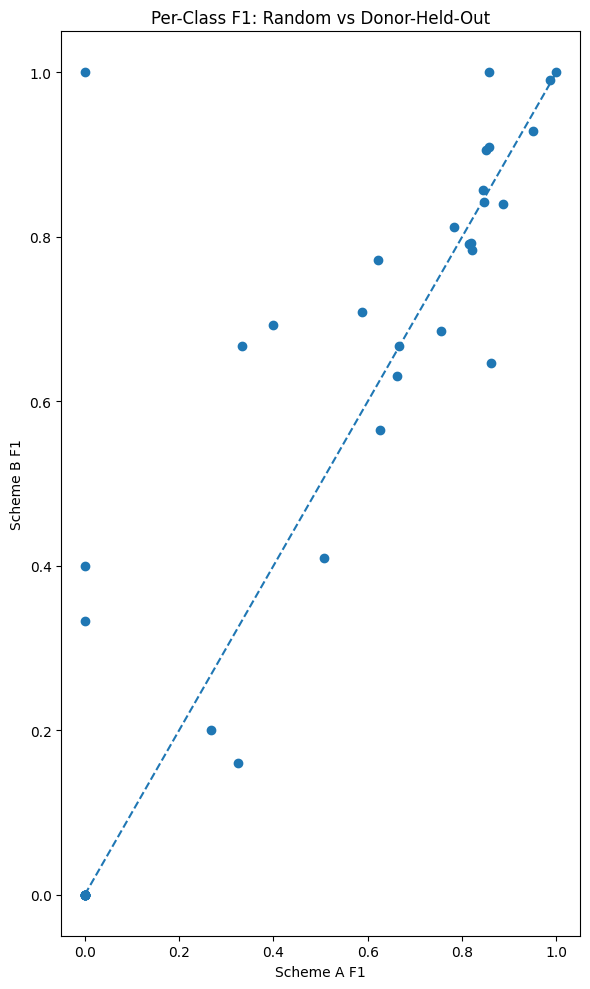

In [28]:
df_A = pd.read_csv("results/schemeA_hvg_per_class_f1.csv")
df_B = pd.read_csv("results/schemeB_hvg_per_class_f1.csv")

df_compare = df_A.merge(df_B, on="cell_type", suffixes=("_A", "_B"))
df_compare["delta_f1"] = df_compare["f1_B"] - df_compare["f1_A"]

print(df_compare.sort_values("delta_f1"))

import matplotlib.pyplot as plt

df_compare = df_compare.sort_values("f1_B")

plt.figure(figsize=(6, 10))
plt.scatter(df_compare["f1_A"], df_compare["f1_B"])

# diagonal line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Scheme A F1")
plt.ylabel("Scheme B F1")
plt.title("Per-Class F1: Random vs Donor-Held-Out")

plt.tight_layout()
plt.show()

In [30]:
df_compare.sort_values("delta_f1", ascending=False).head(10)
df_compare.sort_values("delta_f1").head(10)
df_compare[np.abs(df_compare["delta_f1"]) < 0.02]
df_compare.sort_values("delta_f1").head(10)

,cell_type,f1_A,precision_A,recall_A,support_A,f1_B,precision_B,recall_B,support_B,delta_f1
34,platelet,0.860759,0.871795,0.850000,40.0,0.647059,0.936170,0.494382,89.0,-0.213701
11,T follicular helper cell,0.324324,0.545455,0.230769,26.0,0.160000,0.166667,0.153846,13.0,-0.164324
22,gamma-delta T cell,0.506494,0.549296,0.469880,83.0,0.409639,0.330097,0.539683,63.0,-0.096855
20,"effector memory CD8-positive, alpha-beta T cell",0.755365,0.765217,0.745763,118.0,0.685446,0.708738,0.663636,110.0,-0.069919
36,unswitched memory B cell,0.266667,0.333333,0.222222,9.0,0.200000,0.333333,0.142857,7.0,-0.066667
13,T-helper 22 cell,0.625000,0.615942,0.634328,134.0,0.564972,0.500000,0.649351,77.0,-0.060028
3,"CD16-negative, CD56-bright natural killer cell...",0.886598,0.895833,0.877551,49.0,0.840426,0.822917,0.858696,92.0,-0.046172
18,"effector CD8-positive, alpha-beta T cell",0.820513,0.788732,0.854962,131.0,0.784314,0.782123,0.786517,178.0,-0.036199
14,"central memory CD4-positive, alpha-beta T cell",0.661088,0.619608,0.708520,223.0,0.631325,0.620853,0.642157,204.0,-0.029763
27,myeloid dendritic cell,0.818182,0.818182,0.818182,22.0,0.792453,0.750000,0.840000,25.0,-0.025729
